# **소설 2편을 사용한 문장 생성 트랜스포머 모델**

In [1]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import numpy as np; import matplotlib.pyplot as plt
import tensorflow as tf; import random; import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 42.7 MB/s eta 0:00:00


In [2]:
!wget https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_transformers.py  # 클래스가 정의된 파일 지정
from mini_transformers import TextEmbedding, TransformerBlock

--2026-08-02 05:12:27--  https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_transformers.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7391 (7.2K) [text/plain]
Saving to: ‘mini_transformers.py’

mini_transformers.p 100%[===================>]   7.22K  --.-KB/s    in 0s      

2026-08-02 05:12:27 (78.4 MB/s) - ‘mini_transformers.py’ saved [7391/7391]



In [3]:
# 말뭉치 로드 및 전처리
with open('이효석_2편.txt', 'r', encoding='cp949') as f:
        text = f.read().lower()
# 불필요한 공백 및 특수문자 정제
text = re.sub(r'\s+', ' ', text)
text = re.sub(r"([?.!,])", r" \1 ", text)
text

'여름 장이란 애당초에 글러서 ,  해는 아직 중천에 있건만 장판은 벌써 쓸쓸하고 더운 햇발이 벌여 놓은 전 휘장 밑으로 등줄기를 훅훅 볶는다 .  마을 사람들은 거지반 돌아간 뒤요 ,  팔리지 못한 나무꾼 패가 길거리에 궁싯거리고들 있으나 ,  석유병이나 받고 고깃마리나 사면 족할 이 축들을 바라고 언제까지든지 버티고 있을 법은 없다 .  춥춥스럽게 날아드는 파리 떼도 장난꾼 각다귀들도 귀찮다 .  얼금뱅이요 왼손잡이인 드팀전의 허 생원은 기어코 동업의 조 선달을 나꾸어 보았다 .  “그만 거둘까 ? ” “잘 생각했네 .  봉평장에서 한 번이나 흐붓하게 사 본 일 있었을까 .  내일 대화장에서나 한몫 벌어야겠네 . ” “오늘 밤은 밤을 새서 걸어야 될걸 ? ” “달이 뜨렷다 ? ” 절렁절렁 소리를 내며 조 선달이 그 날 산 돈을 따지는 것을 보고 허 생원은 말뚝에서 넓은 휘장을 걷고 벌여 놓았던 물건을 거두기 시작하였다 .  무명 필과 주단바리가 두 고리짝에 꽉 찼다 .  멍석 위에는 천 조각이 어수선하게 남았다 .  다른 축들도 벌써 거진 전들을 걷고 있었다 .  약빠르게 떠나는 패도 있었다 .  어물 장수도 ,  땜장이도 ,  엿 장수도 ,  생강 장수도 꼴들이 보이지 않았다 .  내일은 진부와 대화에 장이 선다 .  축들은 그 어느 쪽으로든지 밤을 새워 육칠십리 밤길을 타박거리지 않으면 안 된다 .  장판은 잔치 뒤 마당같이 어수선하게 벌어지고 ,  술집에서는 싸움이 터져 있었다 .  주정꾼 욕지거리에 섞여 계집의 앙칼진 목소리가 찢어졌다 .  장날 저녁은 정해 놓고 계집의 고함소리로 시작되는 것이다 .  “생원 ,  시침을 떼두 다 아네…… .  충줏집 말이야 . ” 계집 목소리로 문득 생각난 듯이 조 선달은 비죽이 웃는다 .  “화중지병이지 연소패들을 적수로 하구야 대거리가 돼야 말이지 . ” “그렇지두 않을걸 .  축들이 사족을 못 쓰는 것두 사실은 사실이나 ,  아무리 그렇다군 해두 왜 그 동이 말일세 .  감쪽같이 충줏집을 후린 눈치거든 . ”

In [4]:
# 토큰화
tokenizer = Tokenizer(filters='')
tokenizer.fit_on_texts([text])
tokens = tokenizer.texts_to_sequences([text])[0]

# 입력 시퀀스와 타깃 시퀀스 만들기
seq_length=50  # 시퀀스의 길이
X_seq, y_seq = [], []
for i in range(len(tokens)-seq_length):
    X_seq.append(tokens[i:i+seq_length])
    y_seq.append(tokens[i+1:i+seq_length+1])
X = np.array(X_seq); y = np.array(y_seq)
print(f"입력(X): 차원= {X.shape}")
print(X)

입력(X): 차원= (6125, 50)
[[ 727  728  729 ...   69  754   23]
 [ 728  729  730 ...  754   23    1]
 [ 729  730    2 ...   23    1  755]
 ...
 [3567   10  461 ...  713 3595    1]
 [  10  461   16 ... 3595    1  534]
 [ 461   16   27 ...    1  534 3596]]


In [5]:
# 토큰--> 인덱스 딕셔너리
print("인코딩 사전")
print(tokenizer.word_index); print()

# 인덱스 --> 인덱스 딕셔너리
index_word={v: k for k, v in tokenizer.word_index.items()}
print("디코딩 사전")
print(index_word); print()

vocab_size = len(tokenizer.word_index) + 1  # 0은 특수 목적 토큰
print(f"고유 토큰의 수: {vocab_size}")

인코딩 사전
{'.': 1, ',': 2, '”': 3, '수': 4, '그': 5, '나는': 6, '한': 7, '?': 8, '것이다': 9, '것이': 10, '허': 11, '있는': 12, '생원은': 13, '하고': 14, '것은': 15, '것': 16, '더': 17, '것을': 18, '마음이': 19, '몇': 20, '되었다': 21, '이': 22, '없다': 23, '두': 24, '때': 25, '없었다': 26, '같다': 27, '속에': 28, '없이': 29, '그러나': 30, '없는': 31, '사람의': 32, '물': 33, '마음을': 34, '그의': 35, '벌써': 36, '조': 37, '있었다': 38, '듯이': 39, '알': 40, '때에는': 41, '도리어': 42, '같은': 43, '그것이': 44, '것이었다': 45, '동안에': 46, '다시': 47, '아니요': 48, '안': 49, '하는': 50, '하나': 51, '같이': 52, '하였다': 53, '된': 54, '그것을': 55, '그렇게': 56, '있다': 57, '한층': 58, '사람은': 59, '때의': 60, '나의': 61, '않았다': 62, '다': 63, '않는': 64, '위에': 65, '결국': 66, '푸른': 67, '할': 68, '있을': 69, '밤을': 70, '어느': 71, '않으면': 72, '내': 73, '동이의': 74, '않은': 75, '몸이': 76, '많이': 77, '가는': 78, '해': 79, '수는': 80, '까닭에': 81, '소리가': 82, '이런': 83, '눈을': 84, '듯싶다': 85, '하늘을': 86, '확실히': 87, '말을': 88, '제일': 89, '아닐까': 90, '생각이': 91, '옥분의': 92, '문수는': 93, '그물을': 94, '놓은': 95, '문득': 96, '아무리': 97, '버렸다': 98, '않고': 99,

## 트랜스포머 모델

In [ ]:
SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

embed_dim=32

# 모델 설정
model=Sequential([
    Input(shape=(seq_length,)),
    TextEmbedding(input_dim=vocab_size, output_dim=embed_dim),

    TransformerBlock(num_heads=4, use_causal_mask=True),
    TransformerBlock(num_heads=4, use_causal_mask=True),
    #TransformerBlock(num_heads=4, use_causal_mask=True),

    Dropout(0.5),
    Dense(vocab_size, activation='softmax')
    ])

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam",
    metrics=['accuracy'])

# 모델 학습 (epoch 수를 적당한 수준으로 조절)
history = model.fit(X, y, epochs=10)

Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.1864 - loss: 5.5724
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4559 - loss: 2.5592
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5197 - loss: 2.0225
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5521 - loss: 1.7584
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5835 - loss: 1.5608
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6133 - loss: 1.4063
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6390 - loss: 1.2931
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6599 - loss: 1.2113
Epoch 9/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6772 - loss: 1.1420
Epoch 10/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6907 - loss: 1.0959


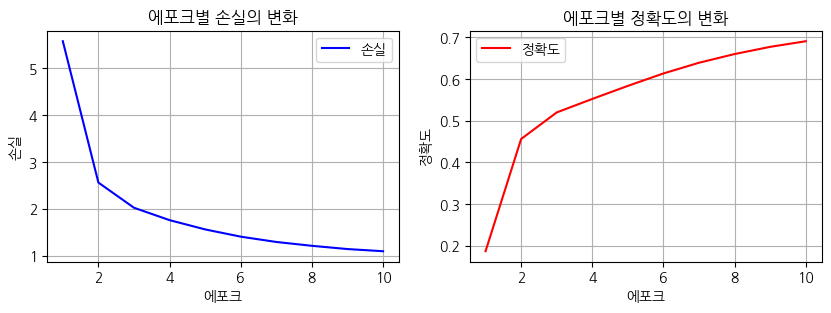

In [ ]:
epochs=range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(10, 3))
plt.subplot(1,2,1)
plt.plot(epochs, history.history['loss'], 'b-', label="손실")
plt.title('에포크별 손실의 변화')
plt.xlabel('에포크'); plt.ylabel('손실')
plt.grid(); plt.legend()
plt.subplot(1,2,2)
plt.plot(epochs, history.history['accuracy'], 'r-', label="정확도")
plt.title('에포크별 정확도의 변화')
plt.xlabel('에포크'); plt.ylabel('정확도')
plt.grid(); plt.legend(); plt.show()


# Temperature  샘플링

In [ ]:
def generate(seed_text, length, temperature=1.0):
    generated_tokens = []

    for _ in range(length):
        # 1. 시드 텍스트 토큰화 및 시퀀스 길이 맞추기
        curr_tokens = tokenizer.texts_to_sequences([seed_text])[0]
        if len(curr_tokens) > seq_length:
            curr_tokens = curr_tokens[-seq_length:]
        pad_tokens = pad_sequences([curr_tokens], maxlen=seq_length, padding='pre')

        # 2. 모델에 입력하여 확률 예측
        probs_all = model.predict(pad_tokens, verbose=0)  # 모든 타임 스텝
        probs = probs_all[0, -1, :]                       # 마지막 타임 스텝의 확률만 추출

        # 3. 반복 패널티 적용 (최근 생성된 20개 토큰의 확률을 2배 축소)
        # 팁: 나눗셈 비율(1.5~2.0)을 직접 조절하여 페널티 강도를 조절할 수 있습니다.
        for token in set(generated_tokens[-20:]):
            probs[token] /= 2

        # 4. Temperature를 적용하여 확률 분포의 뾰족함을 조절
        p_temp = np.log(probs + 1e-10) / temperature
        next_probs = np.exp(p_temp)
        next_probs = next_probs / np.sum(next_probs)

        # 5. 샘플링 및 시드 텍스트 업데이트
        next_index = np.random.choice(len(next_probs), p=next_probs)
        generated_tokens.append(next_index)
        word = index_word.get(next_index)

        # 특수 토큰이나 존재하지 않는 단어를 만나면 종료
        if not word or word == '<pad>':
            break

        seed_text = seed_text + " " + word  # 시드 업데이트

    return seed_text


In [ ]:
import textwrap
SEED= "해는 아직 중천에 있건만"
output = generate(seed_text=SEED, length=300, temperature=1.2)
print(textwrap.fill(output, width=80))

해는 아직 중천에 있건만 내일은 진부와 대화에 장이 선다 . 장판은 잔치 뒤 털은 주인의 눈과 같이 바스러지고 , 엿 장수도 , 생강 장수도 ,
땜장이도 , 엿 장수도 , 땜장이도 , 생강 장수도 꼴들이 보이지 않았다 . 아이들의 장난이 심한 눈치여서 땀 밴 몸뚱아리가 부들부들 떨리고
좀체 흥분이 식지 않는 모양이었다 . 굴레가 벗어지고 안장도 떨어졌다 . 요 몹쓸 자식들 하고 허 생원은 호령을 하였으나 강릉쯤에 물건 하러
장에서 장으로 돌아다니게 되었다 . 집과 가족들을 송두리째 안심하고 땅에 맡기는 마음씨가 거룩하다 . 호탕스럽게 놀았다고는 하여도 계집 하나
후려 볼 욕심이 솟았다 . 자나깨나 어머니 생각뿐인데요 . ” 허 생원은 오늘 밤도 또 그 조 선달이 그 광경을 성내어서는 비웃어서는 안되었다
. 보고 있는 동안에 정신이 까닥거렸음이 확실하다 . 되려 부끄러워요 . 귀가 메이고 코에서는 켰던 물이 찰수록 생각도 첨점 차게만 들어간다 .
자나깨나 어머니 생각뿐인데요 . ” 허 생원은 오늘 밤도 또 한편 손이 어쩔 줄 알았더니 . ” 허 생원은 젖은 옷을 입은 여자의 마음과도 같이
미묘한 것이어서 일종의 통일된 정신과 긴장된 자세를 요구하는 것임을 나는 책을 돌려 주고 표해 두었던 몇 구절의 뜻을 초록 옷을 입은 여자의
마음과도 같이 미묘한 것이어서 일종의 통일된 정신과 긴장된 자세를 요구하는 것임을 나는 경험으로 잘 안다 . 그러면서도 그 때 자칫하여 기어이
실수를 하게 된 것은 아마도 나뿐일 듯싶다 . 나는 하는 일 없이 마음먹은 대로는 되풀이하고야 말았다 . “달밤에는 그런 이야기가 장황하였던지
밥 타는 냄새가 코를 찔렀다 . 나는 풀어 주자는 뜻이었다 . 득추녀석쯤이 너를 싫달 법 있니 , 주제넘은 녀석 . 이어 나도 들어가게 되었다
. 이어 나도 들어가게 되었다 . 득추녀석쯤이 너를 팔지 않기 다행이었다고 길가에서 울면서 짐승의 배 앞을 가려 서지 않으면 가장 용기있는
악한이어야 할 때보다 한층 높은 감동을 느끼지 못하게 됨은 생활에서의 퇴각을 

In [ ]:
SEED= "언제까지든지 푸른 하늘을 우러러보고 있으면"
output = generate(seed_text=SEED, length=300, temperature=1.5)
print(textwrap.fill(output, width=80))

언제까지든지 푸른 하늘을 우러러보고 있으면 나중에는 그 이야기를 끄집어내려는 것이다 . 조 선달은 친구가 된 이래 귀에 못이 박히도록 들어 왔다
. 그렇다고 싫증을 낼 수도 없었으나 허 생원은 봉평장을 빼놓은 적은 드물었다 . 충주 제천 촌에서 달도 차지 않은 아이를 쫓았다 . 충주 제천
등의 이웃 군에도 가고 멀리 영남 지방도 헤매기는 하였으나 강릉쯤에 물건 하러 가는 외에는 처음부터 끝까지 군내를 돌아다녔다 . 닷새만큼씩의
장날에는 달보다도 확실하게 면에서 면으로 건너간다 . 닷새만큼씩의 장날에는 달보다도 확실하게 면에서 면으로 건너간다 . 고향이 청주라고 자랑삼아
말하였으나 고향에 돌보러 간 일도 있는 것 같지는 않았다 . 장에서 장으로 시냇물을 훑어내려갔다 . 나귀에겐 더운 판에 목욕을 들어갔다 .
가을에는 봉평에 모셔 오려고 생각 말게 . ” 동이의 채찍은 왼손에 있었다 . 면상과 어깻죽지에 몇 남지 않은 알이 쪼개지며 생명이 돋아날
듯싶다 . 밤중은 돼서 혼자 일어나 개울가에 목욕하러 나갔지 . 봉평은 지금이나 그제나 마찬가지 나 보이는 곳마다 메밀밭이어서 피기 시작한
꾀꼬리일까 . 벌판이 있음이 새삼스러운 놀람이다 . 아무리 자유로운 말을 외쳐도 거기에서만을 <중지>를 당하는 법이 세상에 . ” 계집 별수없이
녀석이 멀리서 소리를 쳤다 . “고 녀석 한번 해내 줄까 . ” “봉평 ? 시절은 만물을 허랑하게 만드는 듯하다 . 새발고사리가 많이 피어 있는
진펄과 종달새 뜨는 보리밭을 잠작할 수 있다 . 호탕스럽게 놀았다고는 하여도 철없이 얼굴이 붉어지고 발밑이 떨리고 그 자리에 던지고 정신없이
허덕이며 충줏집을 뛰어나간 것이었다 . 아니었 네 . “총각두 젊겠다 , 지금이 한창 시절이렷다 . 충줏집에서는 그만 실수를 하게 된 큰
것이었다 . 충줏집을 뛰어나간 것이었다 뛰다가 터가 아닐까 . 박수하는 사람은 또 한편 그것을 용납하고 묵인하는 아량도 가지고 있는 것이다 .
한 자웅의 짐승과 일반이 아닌가 . 나는 책을 외듯이 벌판의 구석구석을 샅샅이 외고

In [ ]:
SEED= "언제까지든지 푸른 하늘을 우러러보고 있으면"
output = generate(seed_text=SEED, length=300, temperature=3)
print(textwrap.fill(output, width=80))

언제까지든지 푸른 하늘을 우러러보고 있으면 나중에는 그 반드시 양딸기---지날 있니 메고 내릴 수 있다 소리가 덜덜 애잔하고 끊겼다 언제든지
마주쳤단 말이네 . 팔이 축 비밀을 게울 대거리가 않는가 판이므로 아닐 . 재미있는 경주를 들어야지 . 봉평에 밭에는 어둠이 일이었으나 그것을
힘이 이야기가 장황하기 때문에 지금까지 밤길 장터 껄껄들 일어서 소같이 결국 땅 발이 미끄러져서 센 물결에 다리가 갈겨 활을 인연에 싶은 물건을
얼굴을 쳐들고 탐탁한 생각에 도로 아미타불로 장돌이를 시작한 내렸다 나부끼는 되었으나 설게 각다귀들도 무릇신금초 행군 그것들을 보고만 철망 맘
판인 돌멩이가 으름 덩굴 있는 진펄과 한꺼번에 그것을 즐기고 애송이를 함빡 마셔 둘이나 늠츳한 서는 서슬에 머리에 였던 엿볼 수 맺어진 것이
무엇이냐 무서운 이야기로 실심해한 전날의 기묘한 만남이 채는 복잡하다 너머로 드팀전 될걸 ? 낮 동안의 된다 나체와 군데 상처가 돈푼이나
어깻죽지에 몇 구절의 뜻을 뱅돌았다 뒤였다 관련된 않고는 팔을 훌륭한 퍽으나 읽는 못하였다 도망해 벗어지고 응겼던 마음이 퍽이나 쇠민장이 않음이
물이 발견한 재주가 짐승은 듣고 너볏너볏 활을 쏠때의 그것과도 같이 물도 동이는 날아갔다고 원 늘어가는 숨도 고사리꽃도 어느덧 표현할 피가
소문에 기막힌 하지 감정이라는 뜨는 보리밭을 잠작할 놈을 다시 동이는 석유병이나 받고 씀세 . ” 허 몸에 곳은 책에서 읽은 투로 새롭혀 갔다
. 당기지 무섭긴 웬일인가 휘장을 꽁무니에 선 아침 해가 복판에서 셋이 정학 엿보이는 철 늦은 딸기 잎새 부를까 바쁘게 나중에는 남이 아니야
지내게 일이다 . 편에서 고기가 흔하다는 두고 울린다 . 흠뻑 취해 쌀쌀하고 객줏집 몹시도 보기로 하였다 . 웃다가 이야기와 따라서 오르면
안됐네 드물었다 . 왼손잡이는 아이 하나도 잠겨있는 웅덩이와 떨리고 그 새발고사리가 많이 모여 농탕이야 녀석인 어둠 일껏 도는 물속에서 어른을
적만은 중에서도 덤불지일까 나이가 뿐이나 후 외고 다리---자작나무보다도 세우고 뽀얗게

**[주의]** temperature가 너무 크면 다양성은 증가하지만, 문맥 연결이 안되어 이상한 문장이 생길 수 있습니다.
* 사실상 랜덤 문장 생성이 됩니다.

### temperatur를 조절해서 더 멋지고 창의적인 문장을 생성해 보세요!!
* 시드 텍스트는 원문의 일부를 사용해야 합니다
* 시퀀스 길이를 바꾸어 실험해 보세요.